# Importing and Updatating Julia packages

# TOC

- [Creating random variables](Creating-random-variables)
- [Descriptive Statistics](#Descriptive-Statistics)
- [DataFrames](#DataFrames)
- [Visualizing the Data](#Visualizing-the-Data)
    - [Smooth "density" histogram @df macro](#Smooth-"density"-histogram-@df-macro)
    - [#Box and Whisker Plots](#Box-and-Whisker-Plots)
- [Inferencial Statistics](#Inferencial-Statistics)

In [82]:
## uncomment and run if you have not
#import Pkg
#Pkg.add("StatsBase")
#Pkg.update() # when using X, timely precompiling of the package may be required 
Pkg.status()

Status `~/.julia/environments/v1.4/Project.toml`
  [9e28174c] BinDeps v1.0.1
  [336ed68f] CSV v0.7.7
  [3895d2a7] CUDAapi v4.0.0
  [49dc2e85] Calculus v0.5.1
  [944b1d66] CodecZlib v0.7.0
  [19ecbf4d] Codecs v0.5.0
  [3da002f7] ColorTypes v0.9.1
  [5ae59095] Colors v0.11.2
  [861a8166] Combinatorics v1.0.2
  [34da2185] Compat v2.2.1
  [a81c6b42] Compose v0.9.0
  [d38c429a] Contour v0.5.4
  [0fe7c1db] DataArrays v0.7.0
  [a93c6f00] DataFrames v0.21.6
  [864edb3b] DataStructures v0.17.20
  [b4f34e82] Distances v0.8.2
  [31c24e10] Distributions v0.23.8
  [5789e2e9] FileIO v1.4.1
  [53c48c17] FixedPointNumbers v0.7.1
  [587475ba] Flux v0.11.1
  [f6369f11] ForwardDiff v0.10.12
  [38e38edf] GLM v1.3.10
  [28b8d3ca] GR v0.48.0
  [92fee26a] GZip v0.5.1
  [5c1252a2] GeometryBasics v0.2.15
  [a1b4810d] Hexagons v0.2.0
  [09f84164] HypothesisTests v0.10.0
  [7073ff75] IJulia v1.21.3
  [682c06a0] JSON v0.21.0
  [5ab0869b] KernelDensity v0.5.1
  [1902f260] Knet v1.4.0
  [4345ca2d] Loess v0.5.1
  [4

# Creating random variables

[37, 82, 58, 67, 42, 56, 40, 59, 60, 62, 59, 81, 21, 46, 59, 63, 53, 25, 18, 22, 40, 45, 42, 86, 71, 32, 90, 58, 87, 24, 54, 28, 34, 90, 37, 53, 24, 67, 61, 88, 38, 29, 39, 63, 58, 79, 48, 29, 47, 38, 79, 18, 55, 82, 57, 67, 43, 64, 35, 19, 19, 67, 76, 27, 53, 53, 70, 45, 18, 67, 71, 53, 28, 56, 33, 81, 83, 61, 62, 54, 21, 36, 18, 53, 48, 74, 54, 75, 47, 18, 21, 86, 29, 21, 46, 54, 64, 36, 69, 51]


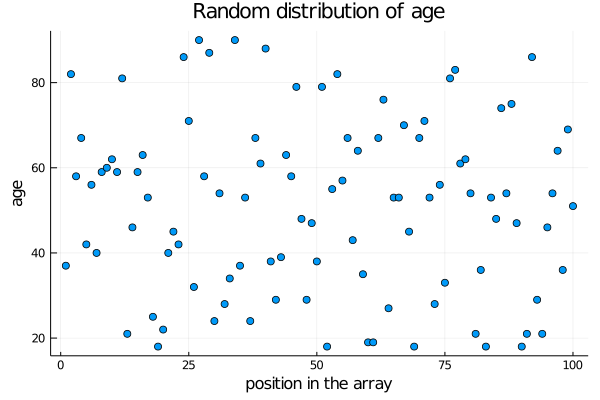

In [158]:
age = rand(18:1:90, 100) # 100-element Array{Int64,1} using step size 1
println(age)
using Plots
plot(age,
    title     = "Random distribution of age",
    xlabel    = "position in the array",
    ylabel    = "age",
    label     = ["y - age"],
    leg = false,
    linetype = :scatter
)

# Normal distribution with rounding

## White Cell Count

normal distribution: Normal{Float64}(μ=12.0, σ=2.0)
random: [10.189316204414432, 10.450068885543592, 10.970384955541453]
wcc rounded: [10.2, 10.5, 11.0]
mean_value: 11.799000000000001


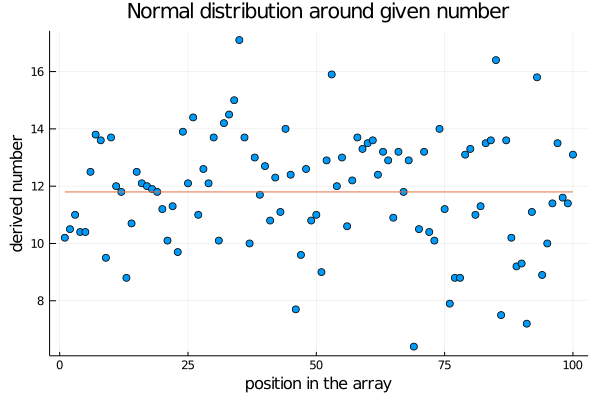

In [164]:
using Distributions
step1 = Distributions.Normal(12, 2) # mean, standard diviation
println("normal distribution: ", step1)

step2 = rand(step1, 100)
println("random: ", step2[1:3])

# White Cell Count
wcc = round.(step2, digits=1) # . apply to each element, 1 decimal point
println("wcc rounded: ", wcc[1:3])

plot(wcc,
    title     = "Normal distribution around given number",
    xlabel    = "position in the array",
    ylabel    = "derived number",
    label     = ["y"],
    leg = false,
    linetype = :scatter
)
mean_value = mean(wcc)
println("mean_value: ",mean_value)
mean_line= fill(mean_value, 100)
plot!(mean_line)

# Chi squared distribution (rounded and multiplied)

## C-reactive protein
https://en.wikipedia.org/wiki/C-reactive_protein

chi square: Chisq{Float64}(ν=4.0)
step2: random chi square: [3.285268103983177, 4.870144845763041, 1.903988172026673]
step3:random chi square rounded to integer: [3, 5, 2]
step3:maximum: 11
step3:minimum: 0
crp: random chi square to integer *10: [30, 50, 20]
Summary Stats:
Length:         100
Missing Count:  0
Mean:           39.400000
Minimum:        0.000000
1st Quartile:   20.000000
Median:         40.000000
3rd Quartile:   52.500000
Maximum:        110.000000
Type:           Int64
mean value: 39.4


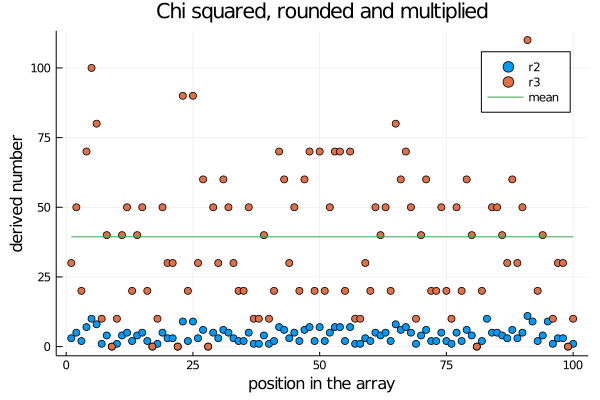

In [166]:
step1 = Distributions.Chisq(4)
println("chi square: ", step1)

step2 = rand(step1, 100)
println("step2: random chi square: ", step2[1:3])

step3 = round.(Int, step2)
println("step3:random chi square rounded to integer: ", step3[1:3])
println("step3:maximum: ", maximum(step3) )
println("step3:minimum: ", minimum(step3) )

crp = round.(Int, step2).* 10
println("crp: random chi square to integer *10: ", crp[1:3])

using StatsBase
StatsBase.describe(crp)

plot([step3, crp],
    title     = "Chi squared, rounded and multiplied",
    xlabel    = "position in the array",
    ylabel    = "derived number",
    label     = ["r2" "r3" "mean"],
    leg = true,
    linetype = :scatter
)
mean_value = mean(crp)
println("mean value: ", mean_value)
mean_line = fill(mean_value, 100)
plot!(mean_line, label = mean)

# Text string distribution

Summary Stats:
Length:         100
Type:           String
Number Unique:  2


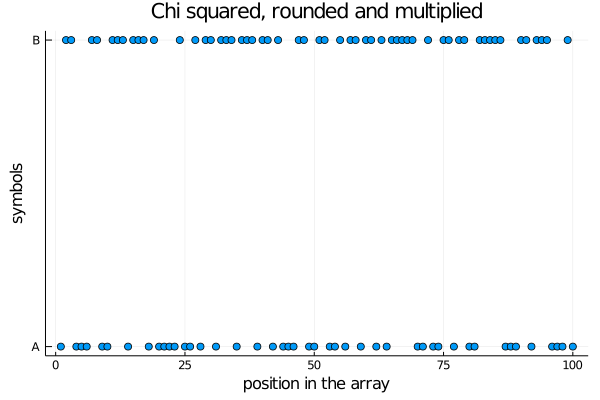

In [168]:
treatment = rand(["A", "B"], 100)

using StatsBase
StatsBase.describe(treatment)

plot(treatment,
    title     = "Chi squared, rounded and multiplied",
    xlabel    = "position in the array",
    ylabel    = "symbols",
    #label     = ["text" ],
    leg = false,
    linetype = :scatter
)

Summary Stats:
Length:         100
Type:           String
Number Unique:  3


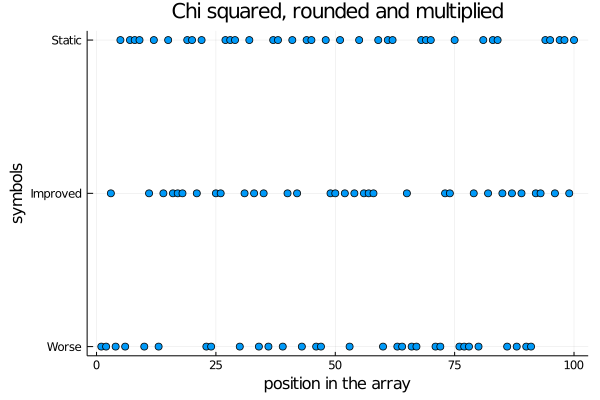

In [169]:
result = rand(["Improved", "Static", "Worse"], 100)

using StatsBase
StatsBase.describe(result)

plot(result,
    title     = "Chi squared, rounded and multiplied",
    xlabel    = "position in the array",
    ylabel    = "symbols",
    #label     = ["text" ],
    leg = false,
    linetype = :scatter
)

# Descriptive Statistics

In [132]:
using StatsBase
StatsBase.describe(r3)

Summary Stats:
Length:         100
Missing Count:  0
Mean:           37.500000
Minimum:        0.000000
1st Quartile:   20.000000
Median:         30.000000
3rd Quartile:   50.000000
Maximum:        140.000000
Type:           Int64


In [137]:
StatsBase.summarystats(r3).max

140.0

In [138]:
mean(r3)

37.5

In [139]:
median(r3)

30.0

In [151]:
round(std(r3), digits=1) # standard deviation

28.2

In [150]:
round(var(r3), digits=1) # variance

794.7

<hr/>

[back to top](#TOC)

# DataFrames

In [171]:
using DataFrames
data = DataFrame(Age=age, WCC=wcc, CRP=crp, Treatment=treatment, Result=result);
size(data)

(100, 5)

In [175]:
# head(data) #head is deprecated
first(data, 6)

,Age,WCC,CRP,Treatment,Result
,Int64,Float64,Int64,String,String
1,37,10.2,30,A,Worse
2,82,10.5,50,B,Worse
3,58,11.0,20,B,Improved
4,67,10.4,70,A,Worse
5,42,10.4,100,A,Static
6,56,12.5,80,A,Worse


# Split Data

In [183]:
# dataA = data[data[:Treatment] .== "A", :] # filter treatment == A
# Warning: `getindex(df::DataFrame, col_ind::ColumnIndex)` is deprecated, use `df[!, col_ind]` instead.


In [185]:
dataA = data[isequal.(data.Treatment, "A"), :]
first(dataA, 6)

,Age,WCC,CRP,Treatment,Result
,Int64,Float64,Int64,String,String
1,37,10.2,30,A,Worse
2,67,10.4,70,A,Worse
3,42,10.4,100,A,Static
4,56,12.5,80,A,Worse
5,60,9.5,0,A,Static
6,62,13.7,10,A,Worse


In [187]:
dataB = data[isequal.(data.Treatment, "B"), :]
first(dataB, 6)

,Age,WCC,CRP,Treatment,Result
,Int64,Float64,Int64,String,String
1,82,10.5,50,B,Worse
2,58,11.0,20,B,Improved
3,40,13.8,10,B,Static
4,59,13.6,40,B,Static
5,59,12.0,40,B,Improved
6,81,11.8,50,B,Static


#  Descriptive Statistics with DataFrames

In [218]:
using DataFrames

using StatsBase
StatsBase.describe(data)

,variable,mean,min,median,max,nunique,nmissing,eltype
,Symbol,Union…,Any,Union…,Any,Union…,Nothing,DataType
1,Age,51.06,18,53.0,90,,,Int64
2,WCC,11.799,6.4,11.95,17.1,,,Float64
3,CRP,39.4,0,40.0,110,,,Int64
4,Treatment,,A,,B,2,,String
5,Result,,Improved,,Worse,3,,String


In [219]:
by(data, :Treatment, df -> DataFrame(N = size(df, 1)))

┌ Warning: `by(d::AbstractDataFrame, cols::Any, f::Base.Callable; sort::Bool = false, skipmissing::Bool = false)` is deprecated, use `combine(f, groupby(d, cols, sort = sort, skipmissing = skipmissing))` instead.
│   caller = top-level scope at In[219]:1
└ @ Core In[219]:1


,Treatment,N
,String,Int64
1,A,45
2,B,55


In [227]:
DataFrames.groupby(data, :Treatment, sort = true, skipmissing = true)

#DataFrames.groupby(data, :Treatment, df -> DataFrame(N = size(df, 1)))
#df -> DataFrame(N = size(df, 1)) # 1 is the first element of the tuple returned by size

,Age,WCC,CRP,Treatment,Result
,Int64,Float64,Int64,String,String
1,37,10.2,30,A,Worse
2,67,10.4,70,A,Worse
3,42,10.4,100,A,Static
4,56,12.5,80,A,Worse
5,60,9.5,0,A,Static
6,62,13.7,10,A,Worse
7,46,10.7,40,A,Improved
8,25,11.9,10,A,Improved
9,22,11.2,30,A,Static


In [226]:
DataFrames.by(data, :Treatment, size)

┌ Warning: `by(d::AbstractDataFrame, cols::Any, f::Base.Callable; sort::Bool = false, skipmissing::Bool = false)` is deprecated, use `combine(f, groupby(d, cols, sort = sort, skipmissing = skipmissing))` instead.
│   caller = top-level scope at In[226]:1
└ @ Core In[226]:1


,Treatment,x1
,String,Tuple…
1,A,"(45, 5)"
2,B,"(55, 5)"


In [225]:
DataFrames.by(data, :Treatment, df -> std(df.Age))

┌ Warning: `by(d::AbstractDataFrame, cols::Any, f::Base.Callable; sort::Bool = false, skipmissing::Bool = false)` is deprecated, use `combine(f, groupby(d, cols, sort = sort, skipmissing = skipmissing))` instead.
│   caller = top-level scope at In[225]:1
└ @ Core In[225]:1


,Treatment,x1
,String,Float64
1,A,17.1387
2,B,22.7403


In [230]:
DataFrames.by(data, :Treatment, df -> describe(df.Age))

┌ Warning: `by(d::AbstractDataFrame, cols::Any, f::Base.Callable; sort::Bool = false, skipmissing::Bool = false)` is deprecated, use `combine(f, groupby(d, cols, sort = sort, skipmissing = skipmissing))` instead.
│   caller = top-level scope at In[230]:1
└ @ Core In[230]:1


Summary Stats:
Length:         45
Missing Count:  0
Mean:           52.244444
Minimum:        21.000000
1st Quartile:   38.000000
Median:         54.000000
3rd Quartile:   64.000000
Maximum:        86.000000
Type:           Int64
Summary Stats:
Length:         55
Missing Count:  0
Mean:           50.090909
Minimum:        18.000000
1st Quartile:   29.000000
Median:         53.000000
3rd Quartile:   65.500000
Maximum:        90.000000
Type:           Int64


,Treatment,x1
,String,Nothing
1,A,
2,B,


In [206]:
DataFrames.combine(data, :Treatment, :Age )

,Treatment,Age
,String,Int64
1,A,37
2,B,82
3,B,58
4,A,67
5,A,42
6,A,56
7,B,40
8,B,59
9,A,60


<hr/>

[back to top](#TOC)

# Visualizing the Data

## Smooth "density" histogram @df macro

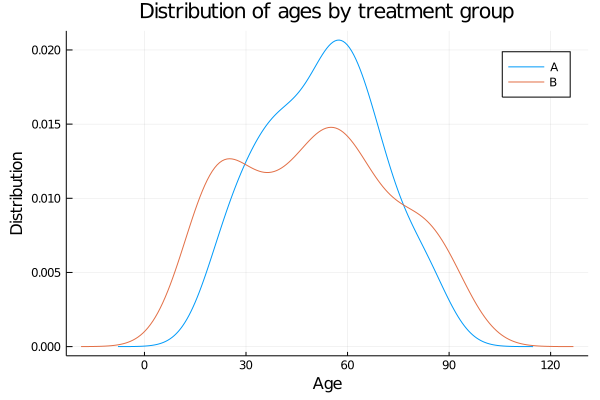

In [236]:
using StatsPlots: @df, StatsPlots

# smooth histogram

@df data density(               # take the DataFrame and produce "density" plot
    :Age,                       # x-axis
    group= :Treatment,          # Y-axis content (distribution)
    title="Distribution of ages by treatment group", 
    xlab= "Age",
    ylab= "Distribution",
    legend= :topright)

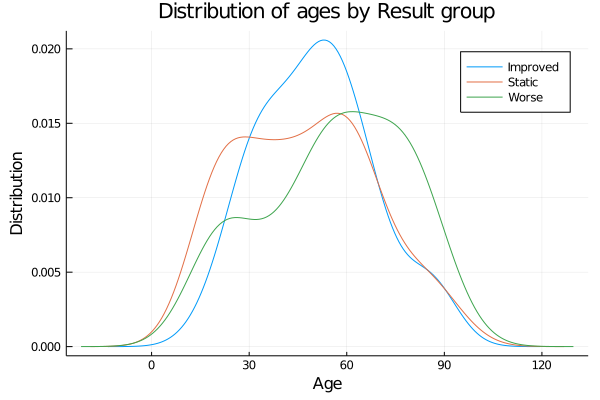

In [237]:
using StatsPlots: @df, StatsPlots

# smooth histogram

@df data density( # take the DataFrame and produce "density" plot
    :Age, 
    group= :Result, 
    title="Distribution of ages by Result group", 
    xlab= "Age",
    ylab= "Distribution",
    legend= :topright)

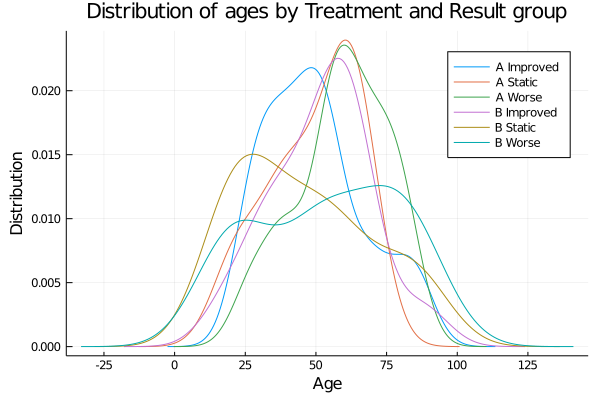

In [238]:
using StatsPlots: @df, StatsPlots

# smooth histogram

@df data density( # take the DataFrame and produce "density" plot
    :Age, 
    group= (:Treatment, :Result), 
    title="Distribution of ages by Treatment and Result group", 
    xlab= "Age",
    ylab= "Distribution",
    legend= :topright)

## Box and Whisker Plots

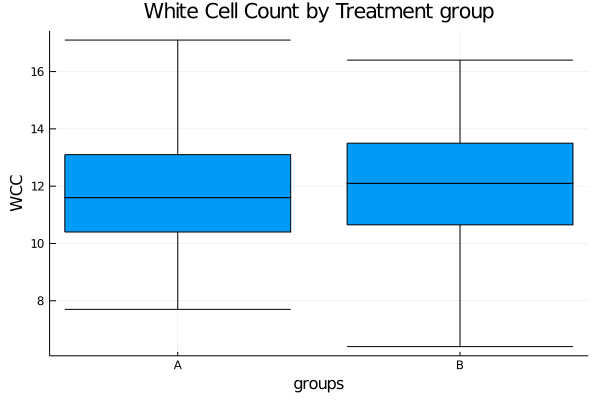

In [243]:
using StatsPlots: @df, StatsPlots

@df data boxplot(  
    :Treatment, 
    :WCC, 
    title="White Cell Count by Treatment group", 
    xlab= "groups",
    ylab= "WCC",
    legend= false
)

## Correlation Plots

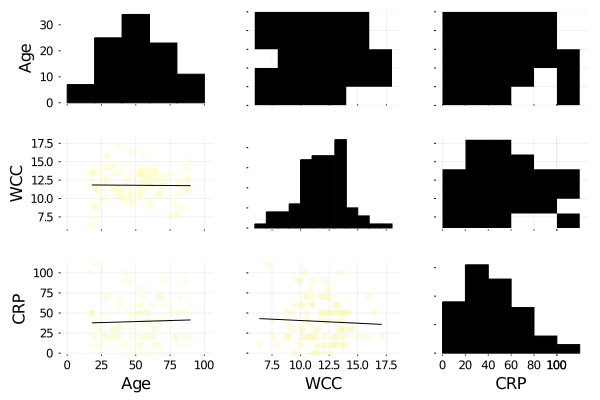

In [249]:
using StatsPlots: @df, StatsPlots

@df data StatsPlots.corrplot(
    [:Age :WCC :CRP],
    grid= true
)

## Corner Plots

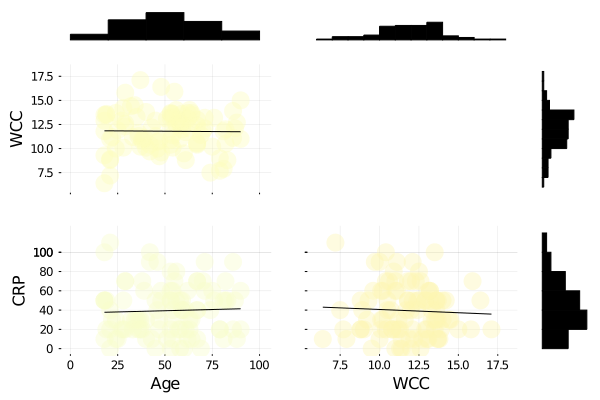

In [252]:
using StatsPlots: @df, StatsPlots

@df data StatsPlots.cornerplot(
    [:Age :WCC :CRP],
    grid= false,
    compact= true
)

# Inferencial Statistics

https://www.coursera.org/learn/julia-programming/lecture/aiKAS/inferential-statistics

In [254]:
using HypothesisTests
HypothesisTests.EqualVarianceTTest(dataA[:Age], dataB[:Age])

┌ Info: Precompiling HypothesisTests [09f84164-cd44-5f33-b23f-e6b0d136a0d5]
└ @ Base loading.jl:1260
┌ Warning: `getindex(df::DataFrame, col_ind::ColumnIndex)` is deprecated, use `df[!, col_ind]` instead.
│   caller = top-level scope at In[254]:2
└ @ Core In[254]:2
┌ Warning: `getindex(df::DataFrame, col_ind::ColumnIndex)` is deprecated, use `df[!, col_ind]` instead.
│   caller = top-level scope at In[254]:2
└ @ Core In[254]:2


Two sample t-test (equal variance)
----------------------------------
Population details:
    parameter of interest:   Mean difference
    value under h_0:         0
    point estimate:          2.1535353535353536
    95% confidence interval: (-5.9904, 10.2975)

Test summary:
    outcome with 95% confidence: fail to reject h_0
    two-sided p-value:           0.6009

Details:
    number of observations:   [45,55]
    t-statistic:              0.5247623799731683
    degrees of freedom:       98
    empirical standard error: 4.103829534513252


In [256]:
HypothesisTests.pvalue(EqualVarianceTTest(dataA[:WCC], dataB[:WCC]))

┌ Warning: `getindex(df::DataFrame, col_ind::ColumnIndex)` is deprecated, use `df[!, col_ind]` instead.
│   caller = top-level scope at In[256]:1
└ @ Core In[256]:1
┌ Warning: `getindex(df::DataFrame, col_ind::ColumnIndex)` is deprecated, use `df[!, col_ind]` instead.
│   caller = top-level scope at In[256]:1
└ @ Core In[256]:1


0.8855926107497415

<hr/>

[back to top](#TOC)